# Análisis FBG: 4 Sensores + Media Polarizaciones (04/02/2026, 15:00-17:30)

✅ **NOTA IMPORTANTE**: En esta adquisición se procesan los **4 sensores FBG** (FBG-1, FBG-2, FBG-3, FBG-4).
Se verificará si FBG-4 tiene datos válidos en este dataset.

Este notebook analiza **sensores FBG** (con 2 polarizaciones cada uno).
Calcula la **media de las polarizaciones** P y S para cada sensor y permite **definir plateaus manualmente**.

## 📋 Configuración:
- **8 RTDs**: 0-3 interiores (1=profundo, 2=medio, 4=superior, 3=superficial), 4-5 vacíos, 6-7 cápsula fibra
- **4 FBGs**: FBG-1, FBG-2, FBG-3, FBG-4 (cada uno con polarización P y S)
- **Análisis**: Media de polarizaciones vs temperatura y presión
- **Plateaus**: Definición manual por presión
- **Acceso a datos**: XRootD remoto vía uproot (no requiere montar /eos/ localmente)

## 💡 Notas sobre el flujo de trabajo:
1. **Visualización de plateaus**: La celda justo antes de la sección 6.2 muestra gráficos superpuestos con líneas verticales marcando los plateaus. Para ver estas líneas correctamente, debes **ejecutar primero la sección 6.3** (definición de plateaus) y **luego re-ejecutar la celda de visualización**.
2. **Evolución temporal completa**: La **Sección 7** al final del notebook muestra todo el rango temporal disponible (no solo 15:00-17:30), permitiendo verificar visualmente el TIME_SHIFT de +2 horas aplicado a los datos de wavelength. Puedes filtrar opcionalmente por rango temporal dentro de esa celda.
3. **Datos de presión**: ✅ En esta adquisición los datos de presión funcionan correctamente y se utilizan para definir los plateaus.

## 1️⃣ Importar Librerías

In [6]:
# Reiniciar kernel si hay problemas con imports
import sys
print(f"Python ejecutable: {sys.executable}")
print(f"Python versión: {sys.version}")

# Verificar que scipy está disponible
try:
    import scipy
    print("✅ scipy disponible")
except ImportError:
    print("❌ scipy no encontrado - instalando...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy"])
    print("✅ scipy instalado - reinicia el kernel")

Python ejecutable: /usr/bin/python3.11
Python versión: 3.11.13 (main, Jan 16 2026, 00:00:00) [GCC 11.5.0 20240719 (Red Hat 11.5.0-11)]
✅ scipy disponible


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
from scipy import stats
import uproot

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2️⃣ Cargar Datos del Archivo ROOT

### 🔍 Listar Archivos Disponibles (Opcional)

Si no estás seguro de qué archivos ROOT existen en el directorio, ejecuta esta celda para listarlos.

In [8]:
# ============================================================================
# CELDA OPCIONAL: Listar archivos .root disponibles en el directorio
# ============================================================================
# Ejecuta esta celda solo si necesitas ver qué archivos existen

try:
    import uproot
    
    # Intentar listar archivos en el directorio
    # Nota: XRootD no soporta listado de directorios directamente con uproot
    # Esta es una alternativa que intenta abrir archivos comunes
    
    base_path = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/"
    print("🔍 Intentando detectar archivos ROOT disponibles...")
    print("=" * 70)
    
    # Lista de fechas comunes a probar (últimos 2 años)
    test_dates = [
        "20260204", "20260202", "20250515", "20250228", "20250202",
        "20260515", "20260101",
        "20240515", "20240228", "20240101"
    ]
    
    found_files = []
    for date in test_dates:
        filepath = f"{base_path}{date}.root"
        try:
            with uproot.open(filepath) as f:
                # Si llega aquí, el archivo existe
                tree = f["resampled_data"]
                n_entries = tree.num_entries
                found_files.append((date, n_entries))
                print(f"✓ {date}.root  ({n_entries:,} entradas)")
        except (FileNotFoundError, KeyError):
            pass  # Archivo no existe
        except Exception as e:
            pass  # Otro error, ignorar
    
    print("=" * 70)
    if found_files:
        print(f"\n✅ Archivos encontrados: {len(found_files)}")
        print("\n💡 Para usar uno de estos archivos:")
        print("   filepath = \"/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/YYYYMMDD.root\"")
    else:
        print("\n⚠️  No se encontraron archivos con fechas comunes.")
        print("\n💡 Verifica la fecha exacta en CERNBox web:")
        print("   https://cernbox.cern.ch/files/")
        
except Exception as e:
    print(f"❌ Error al intentar listar archivos: {e}")
    print("\n💡 Para verificar archivos manualmente:")
    print("   1. Accede a: https://cernbox.cern.ch/")
    print("   2. Navega a tu directorio FBGdata/ROOTFiles/pressure_setup/")
    print("   3. Anota la fecha exacta del archivo (formato: YYYYMMDD.root)")

🔍 Intentando detectar archivos ROOT disponibles...

⚠️  No se encontraron archivos con fechas comunes.

💡 Verifica la fecha exacta en CERNBox web:
   https://cernbox.cern.ch/files/


In [9]:
# 🔧 CONFIGURA AQUÍ LA RUTA DE TU ARCHIVO
# Desde lxplus puedes acceder directamente a /eos/ (montado localmente)
filepath = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260204.root"

# ⚙️ CONFIGURAR TIME_SHIFT (corrección temporal para wavelength)
# Los picos tienen un desfase de +2h respecto a temperatura
TIME_SHIFT = datetime.timedelta(hours=2)  # ✅ Shift confirmado para este dataset

print(f"📂 Cargando archivo ROOT: {filepath}")
print(f"⏱️  TIME_SHIFT configurado: {TIME_SHIFT.total_seconds()/3600:.1f} horas")

# Cargar datos del archivo ROOT
try:
    with uproot.open(filepath) as file:
        # Mostrar trees disponibles
        print(f"✓ Trees disponibles: {file.keys()}")
        
        # Cargar datos de los trees disponibles
        peak_data = file["peak"].arrays(library="np")
        temp_data = file["temp"].arrays(library="np")
        press_data = file["press"].arrays(library="np")
    
    # 🔍 DIAGNÓSTICO: Ver estructura de peak_data
    print(f"\n🔍 Claves en peak_data: {list(peak_data.keys())}")
    for key in peak_data.keys():
        print(f"   {key}: shape = {peak_data[key].shape}")
    
    # Extraer arrays de datos
    times_peak_raw = peak_data["t"][:, 0]  # Tiempos de wavelength
    times_temp_raw = temp_data["t"]  # Tiempos de temperatura
    
    # IMPORTANTE: Convertir wavelength de metros a nanómetros
    wav_raw = peak_data["wav"] * 1e9  # m -> nm
    
    temp_raw = temp_data["temp"]
    press_raw = press_data["press"]
    
    print(f"\n✅ Datos cargados correctamente")
    print(f"   • Wavelength: {wav_raw.shape}")
    print(f"   • Wavelength range: [{np.min(wav_raw[wav_raw > 0]):.2f}, {np.max(wav_raw):.2f}] nm")
    print(f"   • Temperature: {temp_raw.shape}")
    print(f"   • Pressure: {press_raw.shape}")
    
    # Convertir tiempos a datetime SIN aplicar shift aún
    times_peak_original = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in times_peak_raw])
    times_temp = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in times_temp_raw])
    
    # DIAGNÓSTICO: Mostrar rangos SIN SHIFT para comparar
    print(f"\n📅 RANGOS TEMPORALES ORIGINALES (sin shift):")
    print(f"=" * 70)
    print(f"🔵 WAVELENGTH (picos):")
    print(f"   Inicio: {times_peak_original[0].strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"   Fin:    {times_peak_original[-1].strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"\n🔴 TEMPERATURA:")
    print(f"   Inicio: {times_temp[0].strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"   Fin:    {times_temp[-1].strftime('%Y-%m-%d %H:%M:%S')}")
    
    # Calcular diferencia temporal
    diff_inicio = (times_temp[0] - times_peak_original[0]).total_seconds() / 3600
    diff_fin = (times_temp[-1] - times_peak_original[-1]).total_seconds() / 3600
    
    print(f"\n⚠️  DESFASE DETECTADO:")
    print(f"   Temperatura START - Wavelength START: {diff_inicio:+.2f} horas")
    print(f"   Temperatura END - Wavelength END: {diff_fin:+.2f} horas")
    
    if abs(diff_inicio) > 0.5 or abs(diff_fin) > 0.5:
        print(f"\n💡 RECOMENDACIÓN:")
        print(f"   Los datos parecen tener un desfase temporal.")
        if diff_inicio > 0:
            print(f"   Prueba: TIME_SHIFT = datetime.timedelta(hours={abs(diff_inicio):.0f})")
        else:
            print(f"   Prueba: TIME_SHIFT = datetime.timedelta(hours=-{abs(diff_inicio):.0f})")
        print(f"   Luego re-ejecuta esta celda.")
    else:
        print(f"\n✅ Los datos están alineados temporalmente (no necesitas TIME_SHIFT)")
    
    # Aplicar TIME_SHIFT a wavelength
    times_peak = times_peak_original + TIME_SHIFT
    
    # Variable unificada para compatibilidad con el resto del código
    times_raw = times_peak_raw  # Mantener raw para referencia
    times_all = times_peak  # Times con shift aplicado
    
    if TIME_SHIFT.total_seconds() != 0:
        print(f"\n✅ TIME_SHIFT aplicado: {TIME_SHIFT.total_seconds()/3600:.1f}h")
        print(f"   Nuevo rango wavelength:")
        print(f"   Inicio: {times_peak[0].strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"   Fin:    {times_peak[-1].strftime('%Y-%m-%d %H:%M:%S')}")
    
except FileNotFoundError:
    print(f"❌ ERROR: Archivo no encontrado: {filepath}")
    print(f"\n💡 Verifica que el archivo existe en /eos/")
    raise
except Exception as e:
    print(f"❌ ERROR al cargar el archivo: {e}")
    raise

📂 Cargando archivo ROOT: /eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260204.root
⏱️  TIME_SHIFT configurado: 2.0 horas
✓ Trees disponibles: ['peak;9', 'press;3', 'spectrum;2', 'temp;4']

🔍 Claves en peak_data: ['t', 'wav', 'sweep', 'ch', 'pos']
   t: shape = (2421625, 2)
   wav: shape = (2421625, 2, 4)
   sweep: shape = (2421625, 2, 4)
   ch: shape = (2421625, 4)
   pos: shape = (2421625, 4)

✅ Datos cargados correctamente
   • Wavelength: (2421625, 2, 4)
   • Wavelength range: [1543.02, 1560.55] nm
   • Temperature: (9820, 8)
   • Pressure: (19778, 1)

📅 RANGOS TEMPORALES ORIGINALES (sin shift):
🔵 WAVELENGTH (picos):
   Inicio: 2026-02-04 09:44:48
   Fin:    2026-02-04 15:18:35

🔴 TEMPERATURA:
   Inicio: 2026-02-04 11:45:05
   Fin:    2026-02-04 17:16:23

⚠️  DESFASE DETECTADO:
   Temperatura START - Wavelength START: +2.00 horas
   Temperatura END - Wavelength END: +1.96 horas

💡 RECOMENDACIÓN:
   Los datos parecen tener un desfase temporal.
   Prueba: TIME_SHIFT = dateti

### 📊 Visualización de Presión y Temperatura

✅ **En esta adquisición los datos de presión funcionan correctamente**. Este plot muestra la evolución de presión y temperatura durante el experimento.

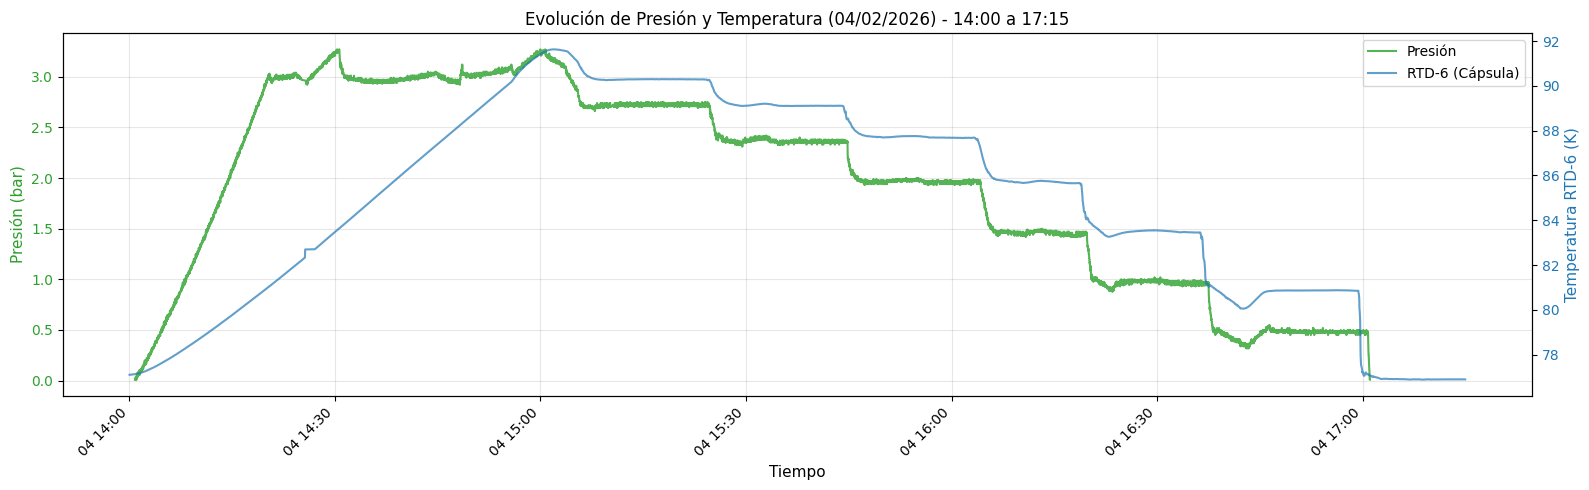


📊 Rango temporal mostrado: 14:00 - 17:15

📊 Estadísticas de presión:
   Rango: [0.01, 3.27] bar
   Media: 1.96 bar
   Std: 0.947 bar
   Puntos válidos: 10,670

📊 Estadísticas de temperatura (RTD-6):
   Rango: [76.88, 91.63] K
   Media: 84.81 K
   Std: 4.516 K
   Puntos válidos: 5,794


In [10]:
# Plot de presión y temperatura superpuestos
fig, ax1 = plt.subplots(1, 1, figsize=(16, 5))

# ============================================================================
# RANGO TEMPORAL PARA VISUALIZACIÓN
# ============================================================================
fecha_plot = datetime.date(2026, 2, 4)
t_plot_inicio_press = datetime.datetime.combine(fecha_plot, datetime.time(14, 0))
t_plot_fin_press = datetime.datetime.combine(fecha_plot, datetime.time(17, 15))

# Extraer tiempos de presión y datos
times_press_raw = press_data["t"]
times_press = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in times_press_raw])

# Verificar dimensiones de press_raw y seleccionar primer sensor si es necesario
if len(press_raw.shape) > 1:
    press_data_plot = press_raw[:, 0]  # Usar primer sensor de presión
else:
    press_data_plot = press_raw

# Filtrar valores positivos Y por rango temporal
press_valid_mask = (press_data_plot > 0) & (times_press >= t_plot_inicio_press) & (times_press <= t_plot_fin_press)
times_press_valid = times_press[press_valid_mask]
press_valid = press_data_plot[press_valid_mask]

# Temperatura (RTD-6 - cápsula fibra)
rtd_ref_idx_preview = 6
temp_preview = temp_raw[:, rtd_ref_idx_preview]
mask_temp_valid = (temp_preview > 0) & (times_temp >= t_plot_inicio_press) & (times_temp <= t_plot_fin_press)
times_temp_valid = times_temp[mask_temp_valid]
temp_valid = temp_preview[mask_temp_valid]

# Eje izquierdo: Presión
color_press = 'tab:green'
ax1.set_xlabel('Tiempo', fontsize=11)
ax1.set_ylabel('Presión (bar)', fontsize=11, color=color_press)
if len(press_valid) > 0:
    ax1.plot(times_press_valid, press_valid, color=color_press, linewidth=1.5, alpha=0.8, label='Presión')
    ax1.tick_params(axis='y', labelcolor=color_press)
else:
    print("⚠️ No hay datos válidos de presión")

# Eje derecho: Temperatura
ax2 = ax1.twinx()
color_temp = 'tab:blue'
ax2.set_ylabel('Temperatura RTD-6 (K)', fontsize=11, color=color_temp)
if len(temp_valid) > 0:
    ax2.plot(times_temp_valid, temp_valid, color=color_temp, linewidth=1.5, alpha=0.7, label='RTD-6 (Cápsula)')
    ax2.tick_params(axis='y', labelcolor=color_temp)

# Título y grid
ax1.set_title(f'Evolución de Presión y Temperatura (04/02/2026) - {t_plot_inicio_press.strftime("%H:%M")} a {t_plot_fin_press.strftime("%H:%M")}', fontsize=12)
ax1.grid(True, alpha=0.3)

# Leyendas combinadas
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

# Rotar etiquetas del eje X
for label in ax1.get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.tight_layout()
plt.show()

print(f"\n📊 Rango temporal mostrado: {t_plot_inicio_press.strftime('%H:%M')} - {t_plot_fin_press.strftime('%H:%M')}")

if len(press_valid) > 0:
    print(f"\n📊 Estadísticas de presión:")
    print(f"   Rango: [{np.min(press_valid):.2f}, {np.max(press_valid):.2f}] bar")
    print(f"   Media: {np.mean(press_valid):.2f} bar")
    print(f"   Std: {np.std(press_valid):.3f} bar")
    print(f"   Puntos válidos: {len(press_valid):,}")

if len(temp_valid) > 0:
    print(f"\n📊 Estadísticas de temperatura (RTD-6):")
    print(f"   Rango: [{np.min(temp_valid):.2f}, {np.max(temp_valid):.2f}] K")
    print(f"   Media: {np.mean(temp_valid):.2f} K")
    print(f"   Std: {np.std(temp_valid):.3f} K")
    print(f"   Puntos válidos: {len(temp_valid):,}")

## 3️⃣ Filtrar Rango Temporal (15:00-17:30)

In [11]:
# Usar times_all que ya incluye el TIME_SHIFT aplicado
times = times_all  # Ya tiene el shift de 2h aplicado

print(f"📅 Rango COMPLETO de datos disponible (wavelength con TIME_SHIFT aplicado):")
print(f"   Inicio: {times[0].strftime('%Y-%m-%d %H:%M:%S')}")
print(f"   Fin:    {times[-1].strftime('%Y-%m-%d %H:%M:%S')}")

# ============================================================================
# ⬅️ AJUSTA AQUÍ EL RANGO TEMPORAL QUE QUIERES ANALIZAR
# ============================================================================
# Opción A: Usar TODO el rango disponible
use_full_range = False  # Cambiar a True para analizar todos los datos

if use_full_range:
    t_inicio = times[0]
    t_fin = times[-1]
else:
    # Opción B: Definir rango específico manualmente
    # ⚠️ AJUSTA ESTOS VALORES según el rango que viste arriba
    fecha = datetime.date(2026, 2, 4)  # ⬅️ CAMBIAR según tu archivo (20260204.root)
    t_inicio = datetime.datetime.combine(fecha, datetime.time(14, 30))
    t_fin = datetime.datetime.combine(fecha, datetime.time(17, 30))

# Filtrar wavelength por rango temporal (ya tiene shift aplicado)
mask_time = (times >= t_inicio) & (times <= t_fin)
times_filtered = times[mask_time]
wav_filtered = wav_raw[mask_time]

# Filtrar temperatura usando sus propios tiempos (sin shift)
mask_time_temp = (times_temp >= t_inicio) & (times_temp <= t_fin)
temp_filtered = temp_raw[mask_time_temp]
times_temp_filtered = times_temp[mask_time_temp]

# Filtrar presión usando sus propios tiempos
mask_time_press = (times_press >= t_inicio) & (times_press <= t_fin)
press_filtered = press_data_plot[mask_time_press]
times_press_filtered = times_press[mask_time_press]

print(f"\n✅ Rango seleccionado para análisis:")
print(f"   {t_inicio.strftime('%Y-%m-%d %H:%M')} - {t_fin.strftime('%H:%M')}")
print(f"   Puntos wavelength en el rango: {len(times_filtered):,}")
print(f"   Puntos temperatura en el rango: {len(times_temp_filtered):,}")
print(f"   Puntos presión en el rango: {len(times_press_filtered):,}")

if len(times_filtered) == 0:
    print(f"\n⚠️ ADVERTENCIA: No hay datos en el rango especificado!")
    print(f"\n💡 Soluciones:")
    print(f"   1. Cambia 'use_full_range = True' para usar todos los datos")
    print(f"   2. O ajusta 't_inicio' y 't_fin' según el rango disponible (ver arriba)")

📅 Rango COMPLETO de datos disponible (wavelength con TIME_SHIFT aplicado):
   Inicio: 2026-02-04 11:44:48
   Fin:    2026-02-04 17:18:35



✅ Rango seleccionado para análisis:
   2026-02-04 14:30 - 17:30
   Puntos wavelength en el rango: 1,264,447
   Puntos temperatura en el rango: 4,992
   Puntos presión en el rango: 9,899


## 4️⃣ Análisis de Temperatura (8 RTDs)

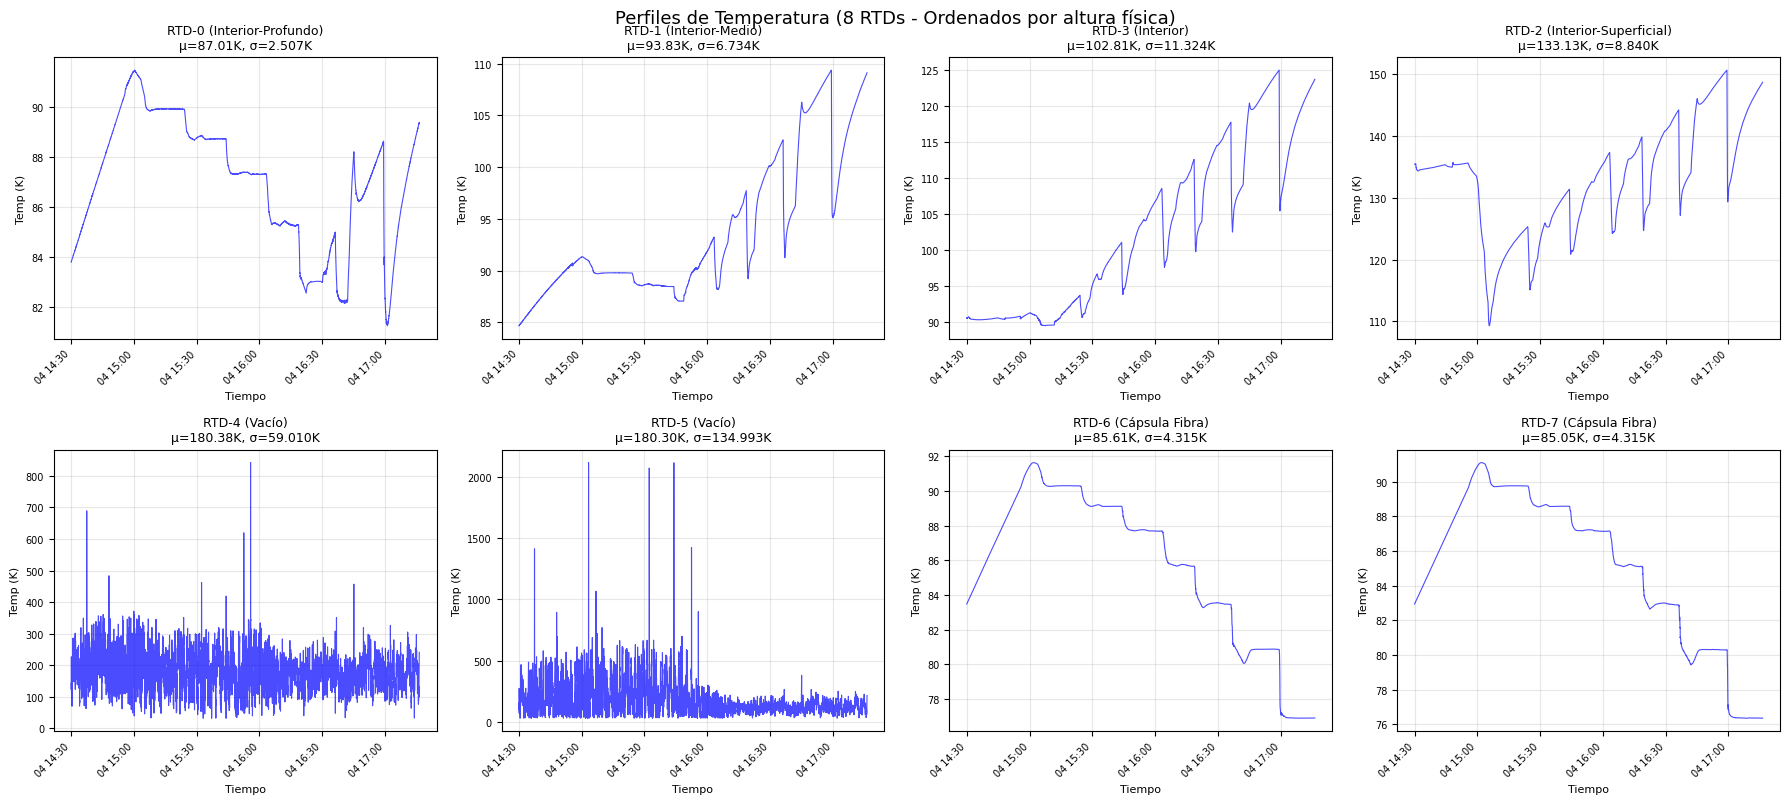


📊 Estadísticas (ordenados por altura física):
RTD-0 (Interior-Profundo)     : μ= 87.01K  σ= 2.507K
RTD-1 (Interior-Medio)        : μ= 93.83K  σ= 6.734K
RTD-3 (Interior)              : μ=102.81K  σ=11.324K
RTD-2 (Interior-Superficial)  : μ=133.13K  σ= 8.840K
RTD-4 (Vacío)                 : μ=180.38K  σ=59.010K
RTD-5 (Vacío)                 : μ=180.30K  σ=134.993K
RTD-6 (Cápsula Fibra)         : μ= 85.61K  σ= 4.315K
RTD-7 (Cápsula Fibra)         : μ= 85.05K  σ= 4.315K


In [12]:
# Configuración RTDs en orden de altura física (de abajo arriba en la vasija)
rtd_sensors_ordered = [
    (0, "RTD-0 (Interior-Profundo)"),      # Más cercano al suelo
    (1, "RTD-1 (Interior-Medio)"),         # Medio
    (3, "RTD-3 (Interior)"),               # Siguiente altura
    (2, "RTD-2 (Interior-Superficial)"),   # Más externo/superficial
    (4, "RTD-4 (Vacío)"),                  # Vacío
    (5, "RTD-5 (Vacío)"),                  # Vacío
    (6, "RTD-6 (Cápsula Fibra)"),          # Dentro de cápsula
    (7, "RTD-7 (Cápsula Fibra)")           # Dentro de cápsula
]

# Plot
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, (sensor_idx, sensor_name) in enumerate(rtd_sensors_ordered):
    temp_sensor = temp_filtered[:, sensor_idx]
    mask_valid = temp_sensor > 0
    times_valid = times_temp_filtered[mask_valid]
    temp_valid = temp_sensor[mask_valid]
    
    if len(temp_valid) > 0:
        axes[idx].plot(times_valid, temp_valid, 'b-', linewidth=0.8, alpha=0.7)
        axes[idx].set_title(f"{sensor_name}\nμ={np.mean(temp_valid):.2f}K, σ={np.std(temp_valid):.3f}K", fontsize=9)
        axes[idx].set_xlabel('Tiempo', fontsize=8)
        axes[idx].set_ylabel('Temp (K)', fontsize=8)
        axes[idx].grid(True, alpha=0.3)
        axes[idx].tick_params(labelsize=7)
        for label in axes[idx].get_xticklabels():
            label.set_rotation(45)
            label.set_ha('right')

plt.tight_layout()
plt.suptitle('Perfiles de Temperatura (8 RTDs - Ordenados por altura física)', fontsize=13, y=1.00)
plt.show()

print("\n📊 Estadísticas (ordenados por altura física):")
for sensor_idx, sensor_name in rtd_sensors_ordered:
    temp_sensor = temp_filtered[:, sensor_idx]
    mask_valid = temp_sensor > 0
    temp_valid = temp_sensor[mask_valid]
    if len(temp_valid) > 0:
        print(f"{sensor_name:30s}: μ={np.mean(temp_valid):6.2f}K  σ={np.std(temp_valid):6.3f}K")

## 5️⃣ Procesamiento FBG: Filtrado y Media de Polarizaciones

### 5.1 Configuración de 4 Sensores FBG

In [13]:
# ✅ CONFIGURACIÓN: 4 sensores FBG completos
# 4 sensores × 2 polarizaciones = 8 canales
# Índices 0-based: sensor 0, 1, 2, 3 (Python indexing)
fbg_config = [
    {"pol": 0, "sensor": 0, "label": "FBG-1-P"},
    {"pol": 1, "sensor": 0, "label": "FBG-1-S"},
    {"pol": 0, "sensor": 1, "label": "FBG-2-P"},
    {"pol": 1, "sensor": 1, "label": "FBG-2-S"},
    {"pol": 0, "sensor": 2, "label": "FBG-3-P"},
    {"pol": 1, "sensor": 2, "label": "FBG-3-S"},
    {"pol": 0, "sensor": 3, "label": "FBG-4-P"},
    {"pol": 1, "sensor": 3, "label": "FBG-4-S"},
]

print(f"✅ Configurados {len(fbg_config)} canales FBG (4 sensores × 2 polarizaciones)")
print(f"💡 Se verificará si FBG-4 tiene datos válidos en este dataset")

✅ Configurados 8 canales FBG (4 sensores × 2 polarizaciones)
💡 Se verificará si FBG-4 tiene datos válidos en este dataset


### 5.2 Filtrado Wavelength (μ±3σ)

In [14]:
def filter_wavelength_data(wav_data, timestamps, sigma_threshold=3.0):
    """Filtra wavelength usando método μ±3σ"""
    mask_positive = wav_data > 0
    wav_positive = wav_data[mask_positive]
    
    # Si no hay datos válidos, retornar estructura vacía
    if len(wav_positive) == 0:
        return {
            "timestamps": np.array([]),
            "wavelength": np.array([]),
            "mean": np.nan,
            "std": np.nan,
            "n_valid": 0
        }
    
    mean_wav = np.mean(wav_positive)
    std_wav = np.std(wav_positive)
    threshold_min = mean_wav - sigma_threshold * std_wav
    threshold_max = mean_wav + sigma_threshold * std_wav
    
    mask_filtered = (wav_data > 0) & (wav_data >= threshold_min) & (wav_data <= threshold_max)
    
    return {
        "timestamps": timestamps[mask_filtered],
        "wavelength": wav_data[mask_filtered],
        "mean": mean_wav,
        "std": std_wav,
        "n_valid": np.sum(mask_filtered)
    }

# DIAGNÓSTICO: Verificar forma y valores de los sensores
print(f"🔍 Forma de wav_filtered: {wav_filtered.shape}")
print(f"   Dimensiones: (time={wav_filtered.shape[0]}, pol={wav_filtered.shape[1]}, sensor={wav_filtered.shape[2]})")

# Diagnóstico por sensor (todos los sensores: 0, 1, 2, 3)
print(f"\n🔍 Diagnóstico de valores por sensor (FBG-1, FBG-2, FBG-3, FBG-4):")
for sensor_idx in range(4):  # 0, 1, 2, 3 (incluye FBG-4)
    for pol_idx in range(2):
        pol_name = "P" if pol_idx == 0 else "S"
        sensor_data = wav_filtered[:, pol_idx, sensor_idx]
        n_positive = np.sum(sensor_data > 0)
        if n_positive > 0:
            min_val = np.min(sensor_data[sensor_data > 0])
            max_val = np.max(sensor_data)
            mean_val = np.mean(sensor_data[sensor_data > 0])
        else:
            min_val = max_val = mean_val = 0
        
        print(f"   FBG-{sensor_idx+1}-{pol_name}: {n_positive:7d} pts > 0, range=[{min_val:.2f}, {max_val:.2f}] nm, μ={mean_val:.2f} nm")

# Procesar todos los canales configurados (incluye FBG-4)
fbg_filtered_data = {}
for cfg in fbg_config:
    wav_data = wav_filtered[:, cfg["pol"], cfg["sensor"]]  # (time, pol, sensor)
    fbg_filtered_data[cfg["label"]] = filter_wavelength_data(wav_data, times_filtered)

print("\n✅ Filtrado completado (4 sensores procesados)")
print(f"\n{'Sensor':<12} {'Mean (nm)':<12} {'Std (nm)':<12} {'N válidos'}")
print("="*60)
for label, data in fbg_filtered_data.items():
    print(f"{label:<12} {data['mean']:<12.6f} {data['std']:<12.6f} {data['n_valid']}")

🔍 Forma de wav_filtered: (1264447, 2, 4)
   Dimensiones: (time=1264447, pol=2, sensor=4)

🔍 Diagnóstico de valores por sensor (FBG-1, FBG-2, FBG-3, FBG-4):
   FBG-1-P: 1264447 pts > 0, range=[1543.03, 1543.11] nm, μ=1543.07 nm
   FBG-1-S: 1264447 pts > 0, range=[1543.03, 1543.09] nm, μ=1543.07 nm


   FBG-2-P: 1264447 pts > 0, range=[1548.10, 1548.82] nm, μ=1548.76 nm
   FBG-2-S: 1264447 pts > 0, range=[1548.12, 1548.81] nm, μ=1548.76 nm
   FBG-3-P: 1264447 pts > 0, range=[1554.60, 1554.68] nm, μ=1554.65 nm
   FBG-3-S: 1264447 pts > 0, range=[1554.61, 1554.67] nm, μ=1554.65 nm
   FBG-4-P: 1264447 pts > 0, range=[1560.42, 1560.50] nm, μ=1560.47 nm
   FBG-4-S: 1264447 pts > 0, range=[1560.43, 1560.49] nm, μ=1560.47 nm

✅ Filtrado completado (4 sensores procesados)

Sensor       Mean (nm)    Std (nm)     N válidos
FBG-1-P      1543.074186  0.021798     1264447
FBG-1-S      1543.066495  0.018637     1264447
FBG-2-P      1548.759041  0.110675     1230015
FBG-2-S      1548.757792  0.100768     1230383
FBG-3-P      1554.647368  0.022584     1264447
FBG-3-S      1554.646530  0.018961     1264447
FBG-4-P      1560.465349  0.022825     1264447
FBG-4-S      1560.467591  0.018683     1264447


### 5.3 Calcular Media de Polarizaciones

In [15]:
# Calcular media P+S para cada sensor (4 sensores: 1, 2, 3, 4)
fbg_mean_data = {}

for sensor_num in [1, 2, 3, 4]:  # Todos los sensores (incluye FBG-4)
    label_p = f"FBG-{sensor_num}-P"
    label_s = f"FBG-{sensor_num}-S"
    label_mean = f"FBG-{sensor_num}-Mean"
    
    data_p = fbg_filtered_data[label_p]
    data_s = fbg_filtered_data[label_s]
    
    times_p = data_p["timestamps"]
    times_s = data_s["timestamps"]
    wav_p = data_p["wavelength"]
    wav_s = data_s["wavelength"]
    
    # Verificar que hay datos válidos
    if len(times_p) == 0 or len(times_s) == 0:
        print(f"⚠️ FBG-{sensor_num} no tiene datos suficientes, omitiendo...")
        continue
    
    # Interpolar S a tiempos de P
    times_p_sec = np.array([t.timestamp() for t in times_p])
    times_s_sec = np.array([t.timestamp() for t in times_s])
    wav_s_interp = np.interp(times_p_sec, times_s_sec, wav_s)
    
    # Media
    wav_mean = (wav_p + wav_s_interp) / 2.0
    
    fbg_mean_data[label_mean] = {
        "timestamps": times_p,
        "wavelength": wav_mean,
        "mean": np.mean(wav_mean),
        "std": np.std(wav_mean),
        "n_valid": len(wav_mean),
        "sensor_num": sensor_num
    }

print("✅ Medias calculadas (P+S)/2 para todos los sensores")
print(f"\n{'Sensor':<15} {'Mean (nm)':<15} {'Std (nm)':<15} {'N puntos'}")
print("="*65)
for label, data in fbg_mean_data.items():
    print(f"{label:<15} {data['mean']:<15.6f} {data['std']:<15.6f} {data['n_valid']}")

✅ Medias calculadas (P+S)/2 para todos los sensores

Sensor          Mean (nm)       Std (nm)        N puntos
FBG-1-Mean      1543.070341     0.020181        1264447
FBG-2-Mean      1548.776386     0.019914        1230015
FBG-3-Mean      1554.646949     0.020737        1264447
FBG-4-Mean      1560.466470     0.020693        1264447


### 5.4 Visualizar Wavelengths (Media de Polarizaciones)

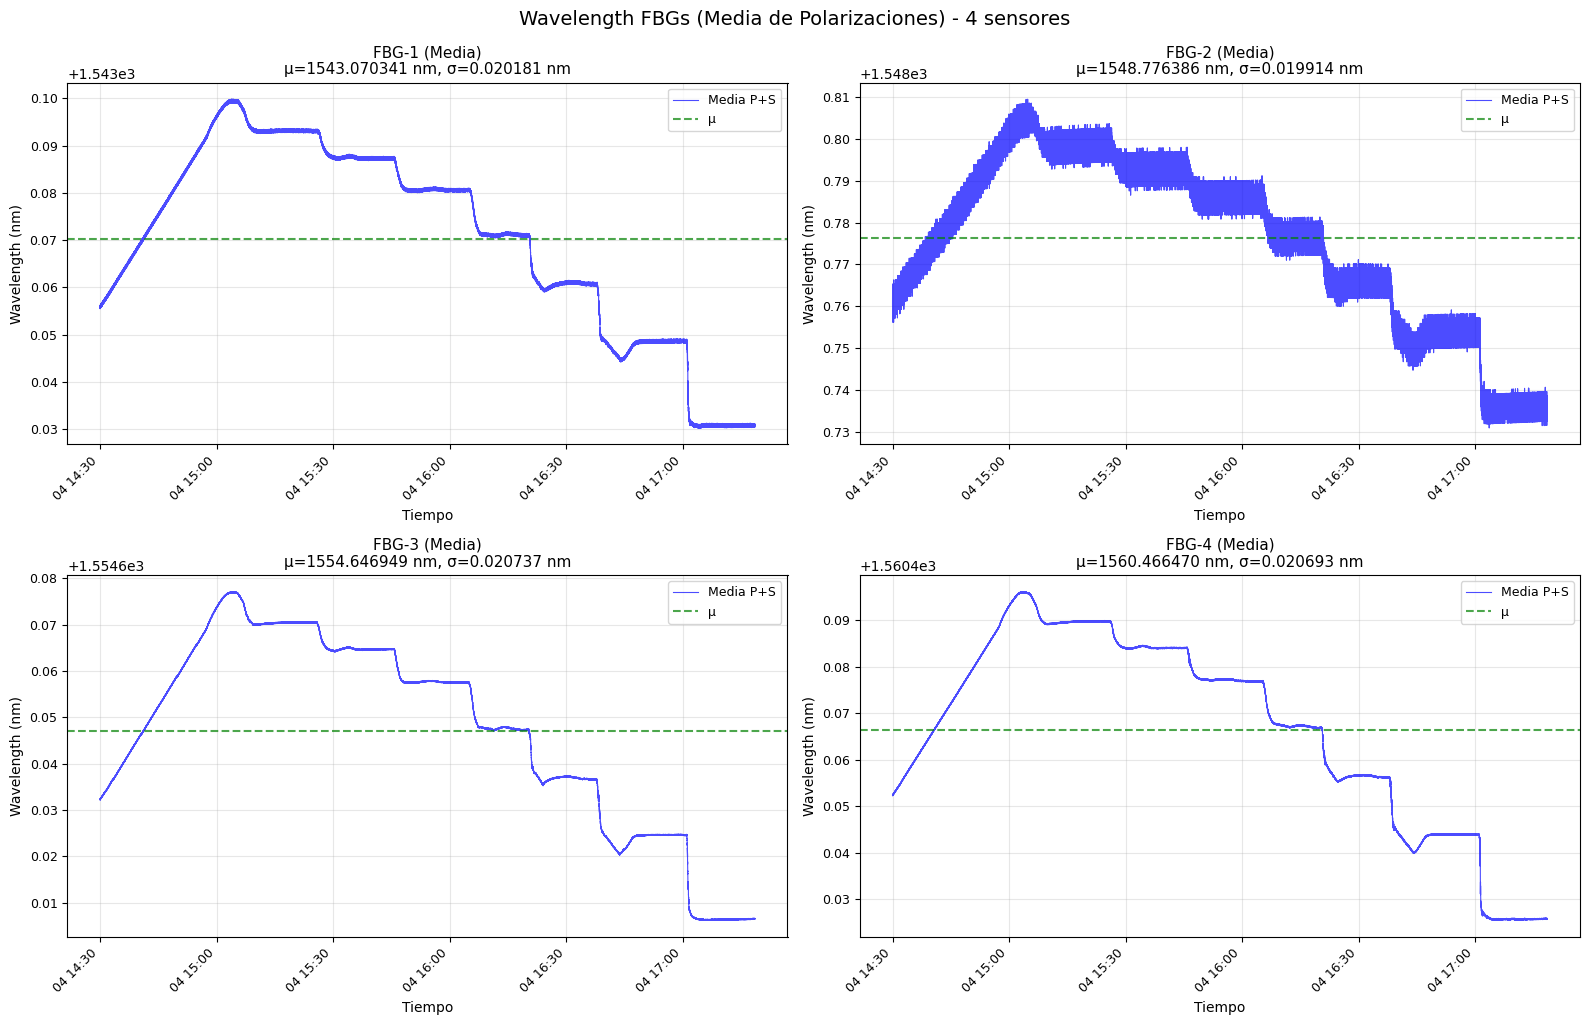

In [16]:
# Ajustar layout para 4 sensores
n_sensors = len(fbg_mean_data)
if n_sensors == 3:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
elif n_sensors == 4:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
else:
    fig, axes = plt.subplots(1, n_sensors, figsize=(6*n_sensors, 5))

if n_sensors == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for idx, (label, data) in enumerate(fbg_mean_data.items()):
    times_fbg = data["timestamps"]
    wav_fbg = data["wavelength"]
    sensor_num = data["sensor_num"]
    
    axes[idx].plot(times_fbg, wav_fbg, 'b-', linewidth=0.8, alpha=0.7, label='Media P+S')
    axes[idx].axhline(data['mean'], color='g', linestyle='--', linewidth=1.5, alpha=0.7, label='μ')
    
    axes[idx].set_title(f"FBG-{sensor_num} (Media)\nμ={data['mean']:.6f} nm, σ={data['std']:.6f} nm", fontsize=11)
    axes[idx].set_xlabel('Tiempo', fontsize=10)
    axes[idx].set_ylabel('Wavelength (nm)', fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(fontsize=9)
    axes[idx].tick_params(labelsize=9)
    
    for tick_label in axes[idx].get_xticklabels():
        tick_label.set_rotation(45)
        tick_label.set_ha('right')

plt.tight_layout()
plt.suptitle(f'Wavelength FBGs (Media de Polarizaciones) - {n_sensors} sensores', fontsize=14, y=1.02)
plt.show()

## 6️⃣ Correlación Temperatura/Presión - Wavelength

### 6.1 Seleccionar RTD de Referencia

In [17]:
# Usar RTD-6 (cápsula fibra) como referencia
rtd_ref_idx = 6
rtd_ref_name = "RTD-6 (Cápsula)"

temp_ref = temp_filtered[:, rtd_ref_idx]
mask_temp_valid = temp_ref > 0
times_temp_ref = times_temp_filtered[mask_temp_valid]
temp_ref_valid = temp_ref[mask_temp_valid]

# Presión válida en el rango filtrado
press_valid_filtered_mask = press_filtered > 0
times_press_ref = times_press_filtered[press_valid_filtered_mask]
press_ref_valid = press_filtered[press_valid_filtered_mask]

print(f"✅ Referencia temperatura: {rtd_ref_name}")
print(f"   Rango: [{np.min(temp_ref_valid):.2f}, {np.max(temp_ref_valid):.2f}] K")
print(f"\n✅ Presión:")
print(f"   Rango: [{np.min(press_ref_valid):.2f}, {np.max(press_ref_valid):.2f}] bar")

✅ Referencia temperatura: RTD-6 (Cápsula)
   Rango: [76.88, 91.63] K

✅ Presión:
   Rango: [0.01, 3.27] bar


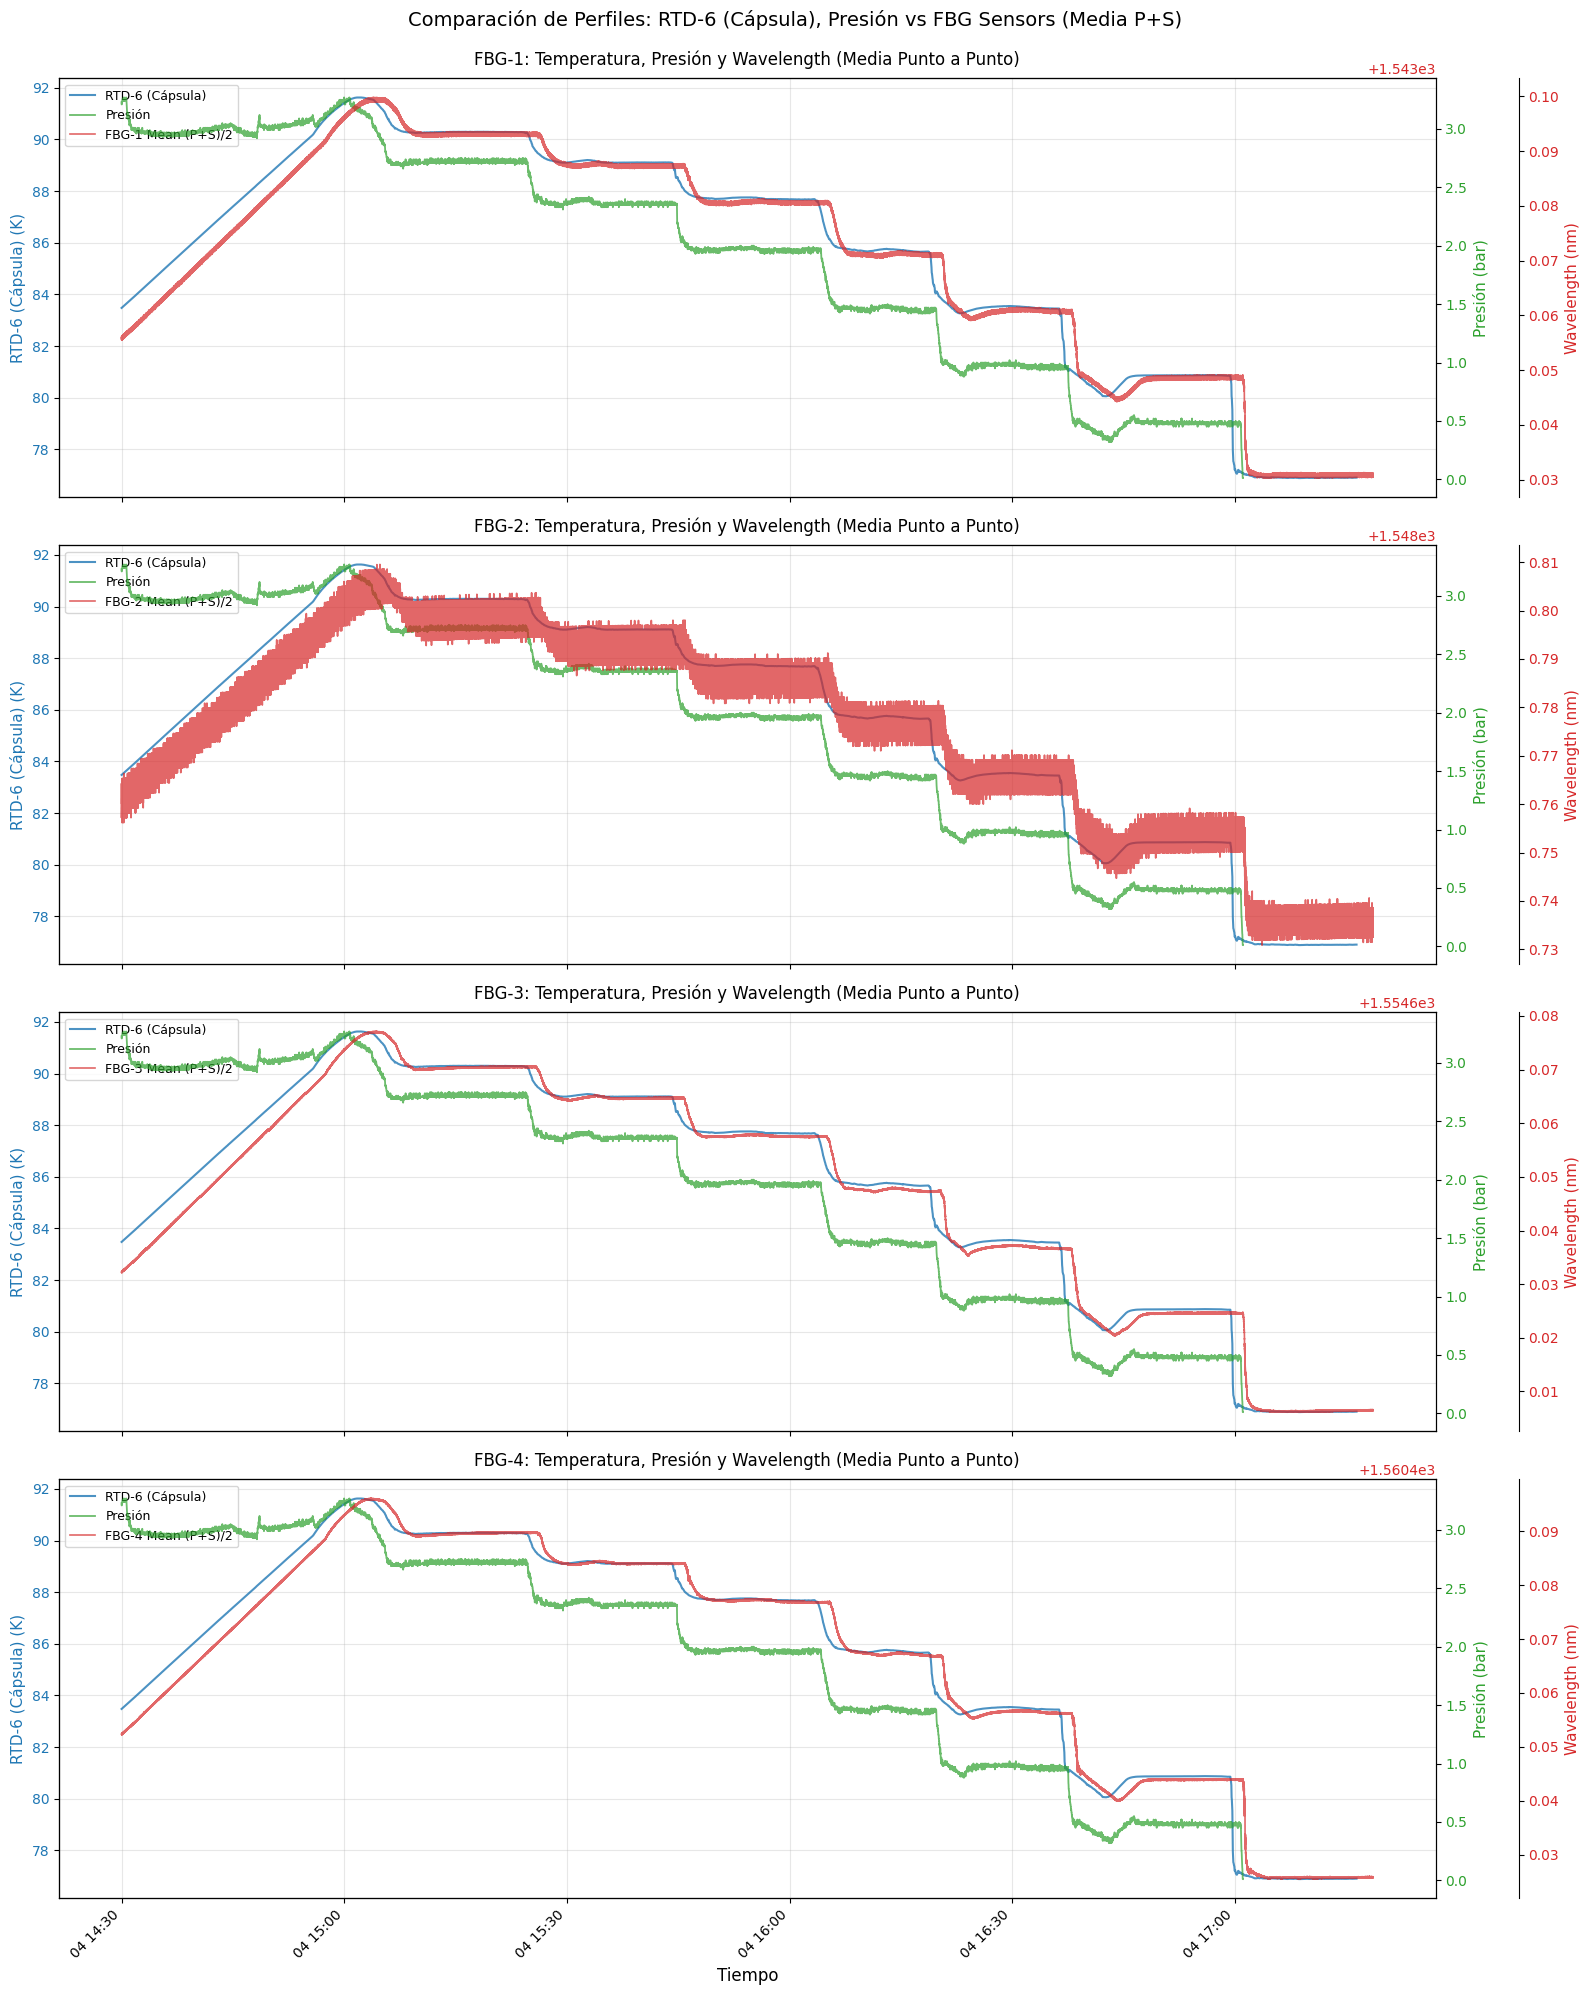

✅ Gráficos superpuestos generados para 4 sensores FBG
   💡 Ejecuta primero la celda 6.3 para ver los plateaus marcados


In [18]:
# Superposición de temperatura, presión y wavelength (subplots para cada FBG)
n_sensors_plot = len(fbg_mean_data)
fig, axes = plt.subplots(n_sensors_plot, 1, figsize=(16, 5*n_sensors_plot), sharex=True)

# Asegurar que axes sea un array
if n_sensors_plot == 1:
    axes = [axes]

color_temp = 'tab:blue'
color_press = 'tab:green'
color_wav = 'tab:red'

for idx, sensor_num in enumerate([1, 2, 3, 4][:n_sensors_plot]):
    fbg_label = f"FBG-{sensor_num}-Mean"
    fbg_data_plot = fbg_mean_data[fbg_label]
    
    ax1 = axes[idx]
    
    # Eje izquierdo: Temperatura
    ax1.set_ylabel(f'{rtd_ref_name} (K)', fontsize=11, color=color_temp)
    ax1.plot(times_temp_ref, temp_ref_valid, color=color_temp, linewidth=1.5, alpha=0.8, label=rtd_ref_name)
    ax1.tick_params(axis='y', labelcolor=color_temp)
    ax1.grid(True, alpha=0.3, axis='both')
    
    # Marcar plateaus con líneas verticales (si están definidos)
    if 'plateau_data' in globals() and len(plateau_data) > 0:
        for plateau in plateau_data:
            ax1.axvline(plateau["t0"], color='red', linestyle='--', linewidth=1.5, alpha=0.6)
            ax1.axvline(plateau["tfin"], color='blue', linestyle='--', linewidth=1.5, alpha=0.6)
    
    # Eje derecho 1: Presión
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 0))
    ax2.set_ylabel('Presión (bar)', fontsize=11, color=color_press)
    ax2.plot(times_press_ref, press_ref_valid, color=color_press, linewidth=1.3, alpha=0.7, label='Presión')
    ax2.tick_params(axis='y', labelcolor=color_press)
    
    # Eje derecho 2: Wavelength (media punto a punto P+S)
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    ax3.set_ylabel('Wavelength (nm)', fontsize=11, color=color_wav)
    ax3.plot(fbg_data_plot["timestamps"], fbg_data_plot["wavelength"], 
             color=color_wav, linewidth=1.2, alpha=0.7, 
             label=f'FBG-{sensor_num} Mean (P+S)/2')
    ax3.tick_params(axis='y', labelcolor=color_wav)
    
    # Leyendas combinadas
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    
    # Añadir leyenda para plateaus si existen
    if 'plateau_data' in globals() and len(plateau_data) > 0 and idx == 0:
        from matplotlib.lines import Line2D
        custom_lines = [Line2D([0], [0], color='red', linestyle='--', linewidth=1.5),
                       Line2D([0], [0], color='blue', linestyle='--', linewidth=1.5)]
        ax1.legend(lines1 + lines2 + lines3 + custom_lines, 
                  labels1 + labels2 + labels3 + ['Inicio plateau', 'Fin plateau'], 
                  loc='upper left', fontsize=9)
    else:
        ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper left', fontsize=9)
    
    # Título del subplot
    ax1.set_title(f'FBG-{sensor_num}: Temperatura, Presión y Wavelength (Media Punto a Punto)', 
                  fontsize=12, pad=10)

# Solo en el último subplot
axes[-1].set_xlabel('Tiempo', fontsize=12)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.suptitle(f'Comparación de Perfiles: {rtd_ref_name}, Presión vs FBG Sensors (Media P+S)', 
             fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

print(f"✅ Gráficos superpuestos generados para {n_sensors_plot} sensores FBG")
if 'plateau_data' in globals() and len(plateau_data) > 0:
    print(f"   🔴🔵 Plateaus marcados con líneas verticales (rojo=inicio, azul=fin)")
else:
    print(f"   💡 Ejecuta primero la celda 6.3 para ver los plateaus marcados")

### 6.2 Visualización de Perfiles (para definir plateaus)

Superposición de temperatura, presión y wavelength para identificar visualmente los plateaus.

### 6.3 Definición Manual de Plateaus

**✏️ Define aquí los intervalos temporales de plateau identificados en los gráficos anteriores**

Plateaus basados en niveles de presión:
- **15:05h**: Pruebo a bajar la presión a 2.75 bar, aguanto 20 minutos en plateau a 2.75 bares y a unos 89K.
- **15:24h**: Bajo a 2.4 bar. Hay una pequeña oscilación porque sube a 2.45 bar en un despiste.
- **15:43h**: Bajo a 2 bar. 87K aprox.
- **16:03h**: Bajo a 1.5 bar.
- **16:18h**: Bajo a 1 bar.
- **16:35h**: Bajo a 0.5 bar. No se estabiliza bien y a las 16:46h intento estabilizarlo de nuevo a 0.54 bar.
- **16:59h**: Bajo a 0 bar.

In [ ]:
# ============================================================================
# DEFINICIÓN MANUAL DE PLATEAUS (basados en niveles de presión)
# ============================================================================
# Formato: [("Nombre", "HH:MM", "HH:MM"), ...]

manual_plateaus = [
    ("Plateau 1 (2.75 bar)", "15:05", "15:24"),
    ("Plateau 2 (2.4 bar)", "15:30", "15:43"),
    ("Plateau 3 (2.0 bar)", "15:46", "16:02"),
    ("Plateau 4 (1.5 bar)", "16:05", "16:17"),
    ("Plateau 5 (1.0 bar)", "16:19", "16:34"),
    ("Plateau 6 (0.5 bar)", "16:36", "16:58"),
    ("Plateau 7 (0 bar)", "17:01", "17:15"),
]

# Activar plateaus manuales
use_manual_plateaus = True

# Procesar plateaus
plateau_data = []

if use_manual_plateaus and len(manual_plateaus) > 0:
    print("✅ Usando plateaus manuales:")
    print("="*80)
    
    for name, t0_str, tfin_str in manual_plateaus:
        t0 = datetime.datetime.combine(fecha, datetime.datetime.strptime(t0_str, "%H:%M").time())
        tfin = datetime.datetime.combine(fecha, datetime.datetime.strptime(tfin_str, "%H:%M").time())
        
        # Calcular media y std de temperatura en el plateau
        mask_temp_plateau = (times_temp_ref >= t0) & (times_temp_ref <= tfin)
        temp_plateau = temp_ref_valid[mask_temp_plateau]
        
        # Calcular media y std de presión en el plateau
        mask_press_plateau = (times_press_ref >= t0) & (times_press_ref <= tfin)
        press_plateau = press_ref_valid[mask_press_plateau]
        
        if len(temp_plateau) > 0:
            temp_mean = np.mean(temp_plateau)
            temp_std = np.std(temp_plateau)
            
            # Calcular media y std de presión (datos siempre disponibles en esta adquisición)
            if len(press_plateau) > 0:
                press_mean = np.mean(press_plateau)
                press_std = np.std(press_plateau)
            else:
                # Si no hay datos de presión en este rango, usar NaN
                press_mean = np.nan
                press_std = np.nan
            
            plateau_info = {
                "name": name,
                "t0": t0,
                "tfin": tfin,
                "temp_mean": temp_mean,
                "temp_std": temp_std,
                "press_mean": press_mean,
                "press_std": press_std,
                "n_temp_points": len(temp_plateau),
                "n_press_points": len(press_plateau)
            }
            
            plateau_data.append(plateau_info)
            
            print(f"{name}: {t0_str} - {tfin_str}")
            print(f"  Temperatura: μ={temp_mean:.3f}K, σ={temp_std:.4f}K, n={len(temp_plateau)}")
            print(f"  Presión:     μ={press_mean:.3f}bar, σ={press_std:.4f}bar, n={len(press_plateau)}")
        else:
            print(f"⚠️ {name}: No hay datos de temperatura en este rango")
    
    print("="*80)
    print(f"\n✅ {len(plateau_data)} plateaus definidos")
else:
    print("ℹ️ Plateaus desactivados")

✅ Usando plateaus manuales:
Plateau 1 (2.75 bar): 15:05 - 15:24
  Temperatura: μ=90.343K, σ=0.1735K, n=570
  Presión:     μ=2.721bar, σ=0.0305bar, n=1129
Plateau 2 (2.4 bar): 15:24 - 15:43
  Temperatura: μ=89.234K, σ=0.2782K, n=570
  Presión:     μ=2.388bar, σ=0.0797bar, n=1130
Plateau 3 (2.0 bar): 15:43 - 16:03
  Temperatura: μ=87.872K, σ=0.3851K, n=600
  Presión:     μ=2.009bar, σ=0.1153bar, n=1189
Plateau 4 (1.5 bar): 16:03 - 16:18
  Temperatura: μ=85.951K, σ=0.5476K, n=450
  Presión:     μ=1.524bar, σ=0.1557bar, n=892
Plateau 5 (1.0 bar): 16:18 - 16:35
  Temperatura: μ=83.677K, σ=0.5562K, n=510
  Presión:     μ=1.027bar, σ=0.1538bar, n=1011
Plateau 6 (0.5 bar): 16:35 - 16:59
  Temperatura: μ=80.946K, σ=0.7460K, n=720
  Presión:     μ=0.519bar, σ=0.1600bar, n=1427
Plateau 7 (0 bar): 16:59 - 17:20
  Temperatura: μ=77.077K, σ=0.7191K, n=522
  Presión:     μ=0.437bar, σ=0.1153bar, n=125

✅ 7 plateaus definidos


### 6.4 Calcular Sensibilidad por Plateaus

Calcula la media y std de wavelength en cada plateau para cada sensor FBG.

In [20]:
# Calcular media y std de wavelength por plateau para cada sensor
plateau_sensitivity_data = {}

for fbg_label, fbg_data in fbg_mean_data.items():
    sensor_num = fbg_data["sensor_num"]
    fbg_times = fbg_data["timestamps"]
    fbg_wav = fbg_data["wavelength"]
    
    plateau_wav_stats = []
    
    for plateau in plateau_data:
        # Máscara para datos de wavelength en este plateau
        mask_wav_plateau = (fbg_times >= plateau["t0"]) & (fbg_times <= plateau["tfin"])
        wav_plateau = fbg_wav[mask_wav_plateau]
        
        if len(wav_plateau) > 0:
            wav_mean = np.mean(wav_plateau)
            wav_std = np.std(wav_plateau)
            
            plateau_wav_stats.append({
                "name": plateau["name"],
                "temp_mean": plateau["temp_mean"],
                "temp_std": plateau["temp_std"],
                "press_mean": plateau["press_mean"],
                "press_std": plateau["press_std"],
                "wav_mean": wav_mean,
                "wav_std": wav_std,
                "n_wav_points": len(wav_plateau)
            })
    
    plateau_sensitivity_data[fbg_label] = plateau_wav_stats

print("✅ Estadísticas de wavelength calculadas por plateau")
print("\nResumen por sensor:")
print("="*80)
for fbg_label in fbg_mean_data.keys():
    sensor_num = fbg_mean_data[fbg_label]["sensor_num"]
    n_plateaus = len(plateau_sensitivity_data[fbg_label])
    print(f"FBG-{sensor_num}: {n_plateaus} plateaus procesados")

✅ Estadísticas de wavelength calculadas por plateau

Resumen por sensor:
FBG-1: 7 plateaus procesados
FBG-2: 7 plateaus procesados
FBG-3: 7 plateaus procesados
FBG-4: 7 plateaus procesados


### 6.5 Visualizar Sensibilidad (Temp vs Wavelength con barras de error)

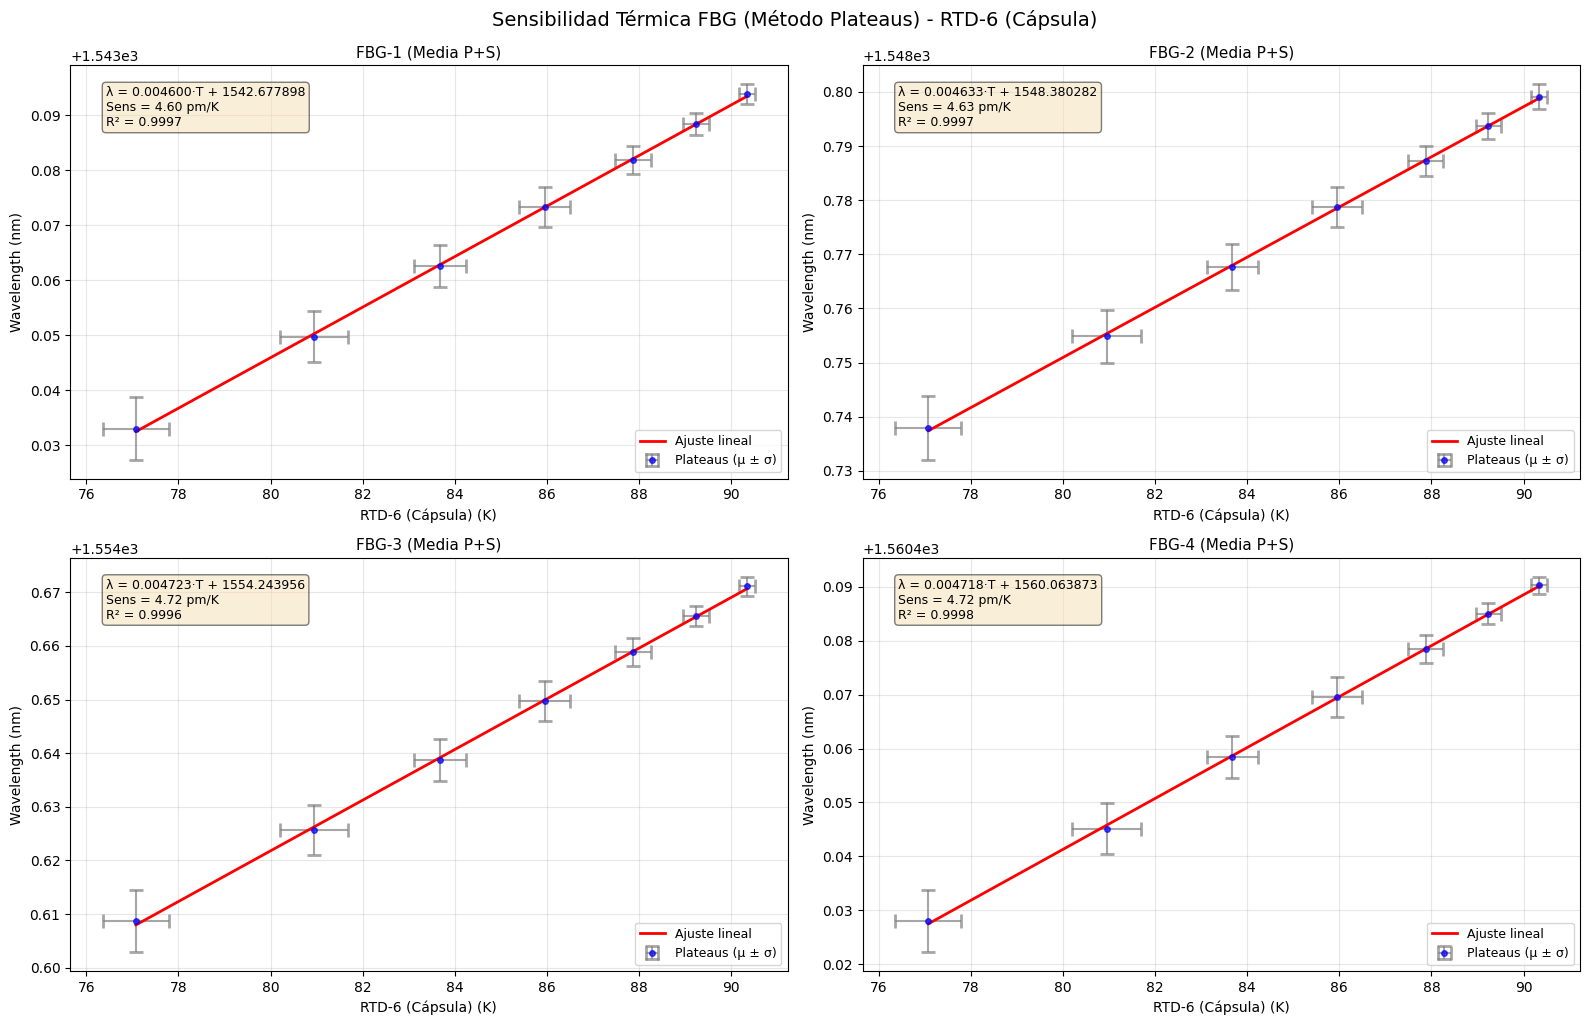


SENSIBILIDADES TÉRMICAS (Método Plateaus)
Sensor          Sensibilidad       R²           N Plateaus   p-value
FBG-1              4.60 pm/K     0.999693     7            5.63e-10
FBG-2              4.63 pm/K     0.999749     7            3.37e-10
FBG-3              4.72 pm/K     0.999573     7            1.28e-09
FBG-4              4.72 pm/K     0.999762     7            2.96e-10


In [21]:
# Ajustar layout para 3 sensores
n_sensors = len(fbg_mean_data)
if n_sensors == 3:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
elif n_sensors == 4:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
else:
    fig, axes = plt.subplots(1, n_sensors, figsize=(6*n_sensors, 5))

if n_sensors == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Diccionario para guardar sensibilidades
plateau_sensitivities = {}

for idx, (fbg_label, fbg_data) in enumerate(fbg_mean_data.items()):
    sensor_num = fbg_data["sensor_num"]
    plateau_stats = plateau_sensitivity_data[fbg_label]
    
    if len(plateau_stats) == 0:
        print(f"⚠️ FBG-{sensor_num}: No hay plateaus con datos")
        continue
    
    # Extraer datos para ajuste lineal
    temp_means = np.array([p["temp_mean"] for p in plateau_stats])
    temp_stds = np.array([p["temp_std"] for p in plateau_stats])
    wav_means = np.array([p["wav_mean"] for p in plateau_stats])
    wav_stds = np.array([p["wav_std"] for p in plateau_stats])
    
    # Ajuste lineal
    slope, intercept, r_value, p_value, std_err = stats.linregress(temp_means, wav_means)
    
    # Guardar sensibilidad
    plateau_sensitivities[fbg_label] = {
        "slope": slope,
        "intercept": intercept,
        "r_squared": r_value**2,
        "p_value": p_value,
        "std_err": std_err,
        "sensitivity_pm_K": slope * 1000,  # nm/K -> pm/K
        "n_plateaus": len(plateau_stats)
    }
    
    # Plot
    ax = axes[idx]
    
    # Puntos con barras de error (markersize más pequeño para ver mejor las barras)
    ax.errorbar(temp_means, wav_means, 
                xerr=temp_stds, yerr=wav_stds,
                fmt='o', markersize=4, capsize=5, capthick=2,
                color='blue', ecolor='gray', alpha=0.7,
                label='Plateaus (μ ± σ)')
    
    # Línea de ajuste
    temp_range = np.array([temp_means.min(), temp_means.max()])
    wav_fit = slope * temp_range + intercept
    ax.plot(temp_range, wav_fit, 'r-', linewidth=2, label='Ajuste lineal')
    
    # Añadir ecuación de la recta en el plot
    sensitivity_pm = slope * 1000
    equation_text = f'λ = {slope:.6f}·T + {intercept:.6f}\n'
    equation_text += f'Sens = {sensitivity_pm:.2f} pm/K\n'
    equation_text += f'R² = {r_value**2:.4f}'
    
    # Posicionar el texto en la esquina superior izquierda
    ax.text(0.05, 0.95, equation_text, 
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Configuración del plot
    ax.set_title(f"FBG-{sensor_num} (Media P+S)", fontsize=11)
    ax.set_xlabel(f'{rtd_ref_name} (K)', fontsize=10)
    ax.set_ylabel('Wavelength (nm)', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.suptitle(f'Sensibilidad Térmica FBG (Método Plateaus) - {rtd_ref_name}', 
             fontsize=14, y=1.02)
plt.show()

# Resumen de sensibilidades
print("\n" + "="*80)
print("SENSIBILIDADES TÉRMICAS (Método Plateaus)")
print("="*80)
print(f"{'Sensor':<15} {'Sensibilidad':<18} {'R²':<12} {'N Plateaus':<12} {'p-value'}")
print("="*80)

for fbg_label in fbg_mean_data.keys():
    if fbg_label in plateau_sensitivities:
        sensor_num = fbg_mean_data[fbg_label]["sensor_num"]
        sens_data = plateau_sensitivities[fbg_label]
        
        print(f"FBG-{sensor_num}        {sens_data['sensitivity_pm_K']:>10.2f} pm/K     "
              f"{sens_data['r_squared']:<12.6f} {sens_data['n_plateaus']:<12d} {sens_data['p_value']:<.2e}")

print("="*80)

### 6.6 Visualizar Sensibilidad (Presión vs Wavelength con barras de error)

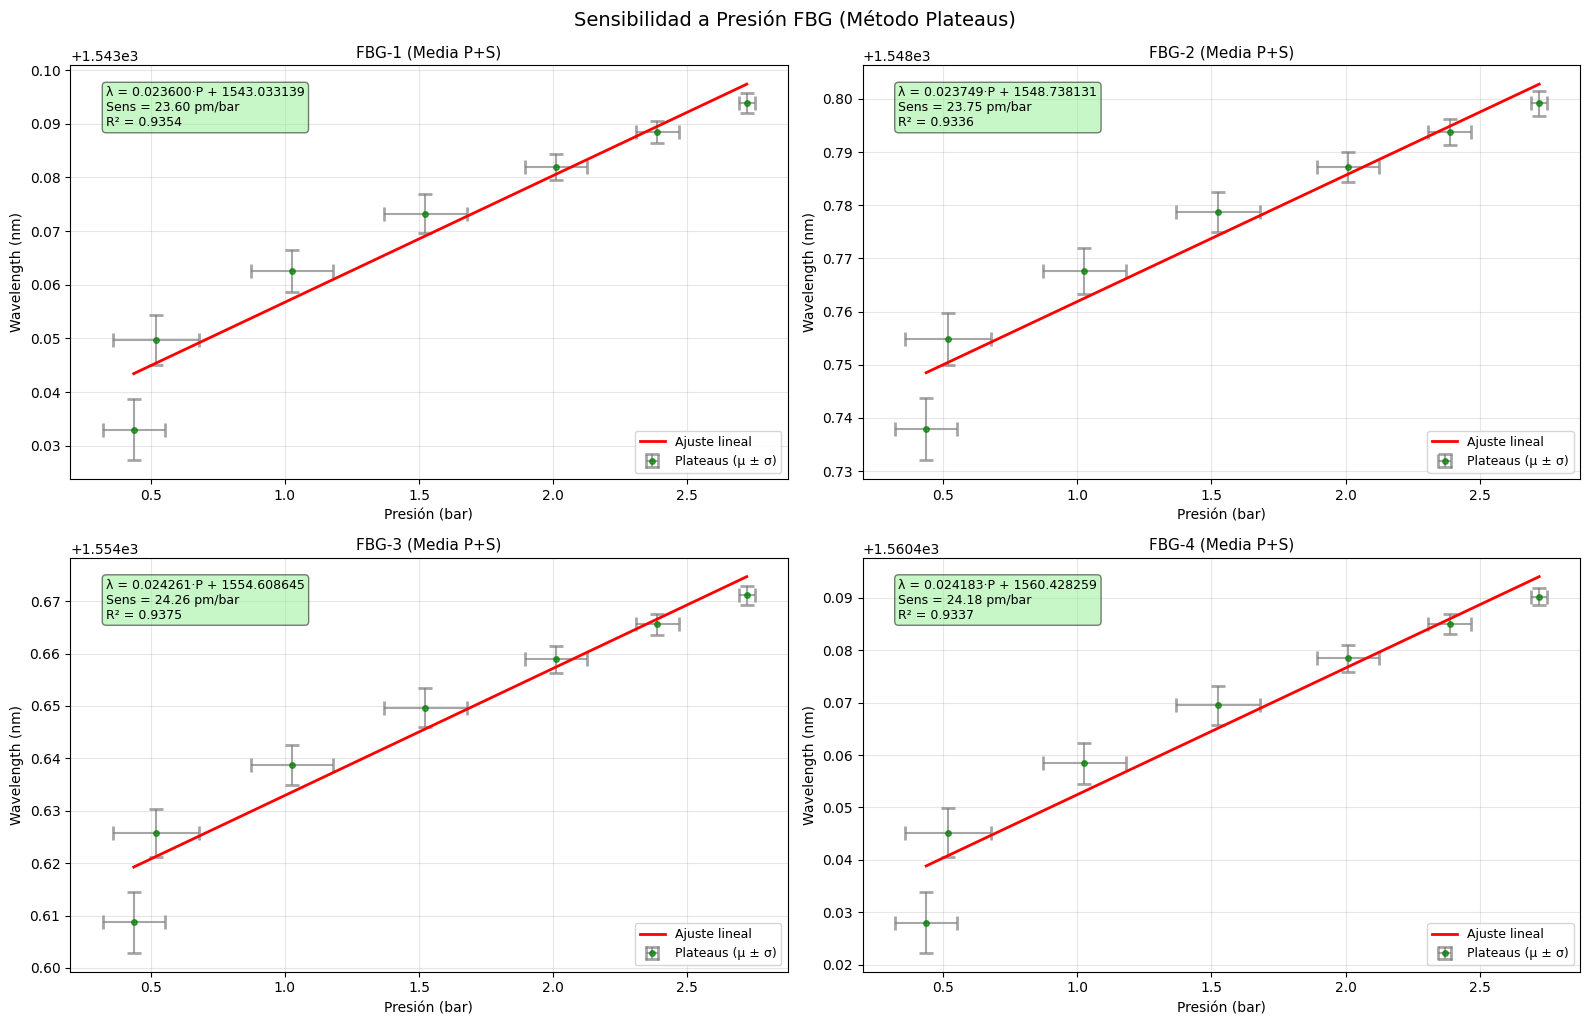


SENSIBILIDADES A PRESIÓN (Método Plateaus)
Sensor          Sensibilidad       R²           N Plateaus   p-value
FBG-1             23.60 pm/bar   0.935359     7            3.69e-04
FBG-2             23.75 pm/bar   0.933629     7            3.95e-04
FBG-3             24.26 pm/bar   0.937539     7            3.39e-04
FBG-4             24.18 pm/bar   0.933661     7            3.94e-04


In [22]:
# Ajustar layout para 3 sensores - Sensibilidad a presión
n_sensors = len(fbg_mean_data)
if n_sensors == 3:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
elif n_sensors == 4:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
else:
    fig, axes = plt.subplots(1, n_sensors, figsize=(6*n_sensors, 5))

if n_sensors == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Diccionario para guardar sensibilidades a presión
plateau_press_sensitivities = {}

for idx, (fbg_label, fbg_data) in enumerate(fbg_mean_data.items()):
    sensor_num = fbg_data["sensor_num"]
    plateau_stats = plateau_sensitivity_data[fbg_label]
    
    if len(plateau_stats) == 0:
        print(f"⚠️ FBG-{sensor_num}: No hay plateaus con datos")
        continue
    
    # Extraer datos para ajuste lineal (presión vs wavelength)
    press_means = np.array([p["press_mean"] for p in plateau_stats])
    press_stds = np.array([p["press_std"] for p in plateau_stats])
    wav_means = np.array([p["wav_mean"] for p in plateau_stats])
    wav_stds = np.array([p["wav_std"] for p in plateau_stats])
    
    # Ajuste lineal
    slope_p, intercept_p, r_value_p, p_value_p, std_err_p = stats.linregress(press_means, wav_means)
    
    # Guardar sensibilidad a presión
    plateau_press_sensitivities[fbg_label] = {
        "slope": slope_p,
        "intercept": intercept_p,
        "r_squared": r_value_p**2,
        "p_value": p_value_p,
        "std_err": std_err_p,
        "sensitivity_pm_bar": slope_p * 1000,  # nm/bar -> pm/bar
        "n_plateaus": len(plateau_stats)
    }
    
    # Plot
    ax = axes[idx]
    
    # Puntos con barras de error
    ax.errorbar(press_means, wav_means, 
                xerr=press_stds, yerr=wav_stds,
                fmt='o', markersize=4, capsize=5, capthick=2,
                color='green', ecolor='gray', alpha=0.7,
                label='Plateaus (μ ± σ)')
    
    # Línea de ajuste
    press_range = np.array([press_means.min(), press_means.max()])
    wav_fit_p = slope_p * press_range + intercept_p
    ax.plot(press_range, wav_fit_p, 'r-', linewidth=2, label='Ajuste lineal')
    
    # Añadir ecuación de la recta en el plot
    sensitivity_pm_bar = slope_p * 1000
    equation_text = f'λ = {slope_p:.6f}·P + {intercept_p:.6f}\n'
    equation_text += f'Sens = {sensitivity_pm_bar:.2f} pm/bar\n'
    equation_text += f'R² = {r_value_p**2:.4f}'
    
    # Posicionar el texto en la esquina superior izquierda
    ax.text(0.05, 0.95, equation_text, 
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
    
    # Configuración del plot
    ax.set_title(f"FBG-{sensor_num} (Media P+S)", fontsize=11)
    ax.set_xlabel('Presión (bar)', fontsize=10)
    ax.set_ylabel('Wavelength (nm)', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.suptitle(f'Sensibilidad a Presión FBG (Método Plateaus)', 
             fontsize=14, y=1.02)
plt.show()

# Resumen de sensibilidades a presión
print("\n" + "="*80)
print("SENSIBILIDADES A PRESIÓN (Método Plateaus)")
print("="*80)
print(f"{'Sensor':<15} {'Sensibilidad':<18} {'R²':<12} {'N Plateaus':<12} {'p-value'}")
print("="*80)

for fbg_label in fbg_mean_data.keys():
    if fbg_label in plateau_press_sensitivities:
        sensor_num = fbg_mean_data[fbg_label]["sensor_num"]
        sens_data = plateau_press_sensitivities[fbg_label]
        
        print(f"FBG-{sensor_num}        {sens_data['sensitivity_pm_bar']:>10.2f} pm/bar   "
              f"{sens_data['r_squared']:<12.6f} {sens_data['n_plateaus']:<12d} {sens_data['p_value']:<.2e}")

print("="*80)

## 7️⃣ Evolución Temporal Completa (Todo el rango con TIME_SHIFT aplicado)

In [23]:
# ============================================================================
# CONFIGURACIÓN: Filtrar por rango temporal (opcional)
# ============================================================================
# Opción A: Mostrar TODO el rango temporal disponible
use_filtered_range_plot = True  # Cambiar a True para filtrar por un rango específico

if use_filtered_range_plot:
    # Opción B: Definir rango específico para visualización
    # Puedes usar el mismo rango de la Sección 3 o definir uno personalizado
    t_plot_inicio = datetime.datetime.combine(fecha, datetime.time(14, 30))
    t_plot_fin = datetime.datetime.combine(fecha, datetime.time(18, 0))
    range_label = f"({t_plot_inicio.strftime('%H:%M')}-{t_plot_fin.strftime('%H:%M')})"
else:
    # Mostrar todo el rango disponible
    t_plot_inicio = times_temp[0]
    t_plot_fin = times_temp[-1]
    range_label = "(Rango completo)"
# ============================================================================

# Ajustar número de subplots según sensores disponibles
n_sensors_temporal = len(fbg_mean_data)
fig, axes = plt.subplots(n_sensors_temporal, 1, figsize=(18, 4*n_sensors_temporal), sharex=True)

# Asegurar que axes sea un array
if n_sensors_temporal == 1:
    axes = [axes]

# Filtrar datos de temperatura según rango seleccionado
temp_raw_valid_mask = (temp_raw[:, rtd_ref_idx] > 0) & \
                       (times_temp >= t_plot_inicio) & \
                       (times_temp <= t_plot_fin)
times_temp_plot = times_temp[temp_raw_valid_mask]
temp_plot = temp_raw[temp_raw_valid_mask, rtd_ref_idx]

for idx, sensor_num in enumerate([1, 2, 3, 4][:n_sensors_temporal]):
    fbg_label = f"FBG-{sensor_num}-Mean"
    
    # Extraer datos RAW completos
    sensor_idx = sensor_num - 1  # 0-indexed
    wav_p_full = wav_raw[:, 0, sensor_idx]  # Polarización P
    wav_s_full = wav_raw[:, 1, sensor_idx]  # Polarización S
    
    # Filtrar valores positivos y por rango temporal
    mask_p = (wav_p_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    mask_s = (wav_s_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    
    times_p_plot = times_peak[mask_p]
    times_s_plot = times_peak[mask_s]
    wav_p_plot_valid = wav_p_full[mask_p]
    wav_s_plot_valid = wav_s_full[mask_s]
    
    # Interpolar S a tiempos de P
    times_p_sec = np.array([t.timestamp() for t in times_p_plot])
    times_s_sec = np.array([t.timestamp() for t in times_s_plot])
    wav_s_interp_plot = np.interp(times_p_sec, times_s_sec, wav_s_plot_valid)
    
    # Media (P+S)/2
    wav_mean_plot = (wav_p_plot_valid + wav_s_interp_plot) / 2.0
    
    ax = axes[idx]
    
    # Plot temperatura
    ax.plot(times_temp_plot, temp_plot, 'b-', linewidth=1.0, alpha=0.6, label=f'{rtd_ref_name}')
    ax.set_ylabel('Temperatura (K)', fontsize=10, color='b')
    ax.tick_params(axis='y', labelcolor='b')
    ax.grid(True, alpha=0.3)
    
    # Plot wavelength en eje secundario
    ax2 = ax.twinx()
    ax2.plot(times_p_plot, wav_mean_plot, 'r-', linewidth=0.8, alpha=0.7, label=f'FBG-{sensor_num} Mean')
    ax2.set_ylabel('Wavelength (nm)', fontsize=10, color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    
    # Leyenda combinada
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    
    ax.set_title(f'FBG-{sensor_num}: Evolución Temporal {range_label} (TIME_SHIFT = +{TIME_SHIFT.total_seconds()/3600:.0f}h aplicado a wavelength)', 
                 fontsize=11)

# Configurar eje X solo en el último subplot
axes[-1].set_xlabel('Tiempo', fontsize=11)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.suptitle(f'Evolución Temporal: {rtd_ref_name} vs FBG Sensors (con TIME_SHIFT)', 
             fontsize=13, y=0.995)
plt.tight_layout()
plt.show()

print(f"\n📊 Rango temporal mostrado: {range_label}")
print(f"   Temperatura: {times_temp_plot[0].strftime('%Y-%m-%d %H:%M')} - {times_temp_plot[-1].strftime('%H:%M')}")
print(f"   Wavelength (con +{TIME_SHIFT.total_seconds()/3600:.0f}h shift): {times_p_plot[0].strftime('%Y-%m-%d %H:%M')} - {times_p_plot[-1].strftime('%H:%M')}")

print(f"\n💡 Este gráfico muestra el TIME_SHIFT de {TIME_SHIFT.total_seconds()/3600:.0f} horas aplicado a los datos de wavelength")    print(f"\n⚙️  Para filtrar por rango temporal específico: cambia 'use_filtered_range_plot = True'")

print(f"   para alinearlos temporalmente con la temperatura.")else:

if use_filtered_range_plot:    print(f"\n⚙️  Para ver el rango completo: cambia 'use_filtered_range_plot = False'")

SyntaxError: invalid syntax (881696854.py, line 97)

## 8️⃣ Resumen Final

In [ ]:
print("\n" + "="*80)
print("RESUMEN COMPLETO DEL ANÁLISIS")
print("="*80)
print(f"Archivo: {filepath}")
print(f"Rango: {t_inicio.strftime('%Y-%m-%d %H:%M')} - {t_fin.strftime('%H:%M')}")
print(f"Temperatura referencia: {rtd_ref_name}")
print(f"Presión: ✅ Datos funcionales")
print(f"Plateaus manuales: {'SÍ' if use_manual_plateaus else 'NO'}")

print("\n" + "="*80)
print("SENSIBILIDADES TÉRMICAS (Media P+S):")
print("="*80)
print(f"{'Sensor':<15} {'Sensibilidad':<18} {'R²':<10} {'Calidad'}")
print("="*80)

all_sensitivities = []
for label, data in fbg_mean_data.items():
    if label not in plateau_sensitivities:
        continue
    
    sensor_num = data["sensor_num"]
    sens = plateau_sensitivities[label]
    sensitivity_pm = sens['sensitivity_pm_K']
    all_sensitivities.append(sensitivity_pm)
    
    r2 = sens['r_squared']
    if r2 > 0.99:
        quality = "Excelente ✓✓✓"
    elif r2 > 0.95:
        quality = "Muy bueno ✓✓"
    elif r2 > 0.90:
        quality = "Bueno ✓"
    else:
        quality = "Regular ⚠"
    
    print(f"FBG-{sensor_num}        {sensitivity_pm:>10.2f} pm/K     {r2:<10.6f} {quality}")

print("="*80)
print(f"\nESTADÍSTICAS GLOBALES (Sensibilidad Térmica):")
print(f"  Media: {np.mean(all_sensitivities):.2f} pm/K")
print(f"  Std: {np.std(all_sensitivities):.3f} pm/K")
print(f"  Rango: [{np.min(all_sensitivities):.2f}, {np.max(all_sensitivities):.2f}] pm/K")

print("\n" + "="*80)
print("SENSIBILIDADES A PRESIÓN (Media P+S):")
print("="*80)
print(f"{'Sensor':<15} {'Sensibilidad':<18} {'R²':<10} {'Calidad'}")
print("="*80)

all_press_sensitivities = []
for label, data in fbg_mean_data.items():
    if label not in plateau_press_sensitivities:
        continue
    
    sensor_num = data["sensor_num"]
    sens = plateau_press_sensitivities[label]
    sensitivity_pm_bar = sens['sensitivity_pm_bar']
    all_press_sensitivities.append(sensitivity_pm_bar)
    
    r2 = sens['r_squared']
    if r2 > 0.99:
        quality = "Excelente ✓✓✓"
    elif r2 > 0.95:
        quality = "Muy bueno ✓✓"
    elif r2 > 0.90:
        quality = "Bueno ✓"
    else:
        quality = "Regular ⚠"
    
    print(f"FBG-{sensor_num}        {sensitivity_pm_bar:>10.2f} pm/bar   {r2:<10.6f} {quality}")

print("="*80)
print(f"\nESTADÍSTICAS GLOBALES (Sensibilidad a Presión):")
print(f"  Media: {np.mean(all_press_sensitivities):.2f} pm/bar")
print(f"  Std: {np.std(all_press_sensitivities):.3f} pm/bar")
print(f"  Rango: [{np.min(all_press_sensitivities):.2f}, {np.max(all_press_sensitivities):.2f}] pm/bar")
print("="*80)


RESUMEN COMPLETO DEL ANÁLISIS
Archivo: /eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260204.root
Rango: 2026-02-04 15:00 - 17:30
Temperatura referencia: RTD-6 (Cápsula)
Presión: ✅ Datos funcionales
Plateaus manuales: SÍ

SENSIBILIDADES TÉRMICAS (Media P+S):
Sensor          Sensibilidad       R²         Calidad
FBG-1              4.60 pm/K     0.999693   Excelente ✓✓✓
FBG-2              4.63 pm/K     0.999749   Excelente ✓✓✓
FBG-3              4.72 pm/K     0.999573   Excelente ✓✓✓

ESTADÍSTICAS GLOBALES (Sensibilidad Térmica):
  Media: 4.65 pm/K
  Std: 0.052 pm/K
  Rango: [4.60, 4.72] pm/K

SENSIBILIDADES A PRESIÓN (Media P+S):
Sensor          Sensibilidad       R²         Calidad
FBG-1             23.60 pm/bar   0.935359   Bueno ✓
FBG-2             23.75 pm/bar   0.933629   Bueno ✓
FBG-3             24.26 pm/bar   0.937539   Bueno ✓

ESTADÍSTICAS GLOBALES (Sensibilidad a Presión):
  Media: 23.87 pm/bar
  Std: 0.283 pm/bar
  Rango: [23.60, 24.26] pm/bar


## 📝 Guía de Uso

### Pasos básicos:
1. **Celda 2**: Cambiar ruta del archivo ROOT (20260204.root)
2. **Celda 3**: Ajustar rango horario si es necesario (15:00-17:30)
3. **Celda 6.1**: Seleccionar RTD de referencia
4. **Celda 6.2**: Visualizar perfiles Temp/Presión-Wavelength para identificar plateaus
5. **Celda 6.3**: Definir plateaus manuales con intervalos temporales
6. **Ejecutar todo**: Run All

### Configuración:
- **RTD referencia**: Celda 6.1 → `rtd_ref_idx` (6 = RTD-6 "Cápsula")
- **Plateaus**: Celda 6.3 → editar `manual_plateaus` con intervalos estables
- **Rango temporal**: Celda 3 → `t_inicio`, `t_fin`

### Método de plateaus:
El análisis calcula sensibilidades usando **plateaus manuales basados en presión**:
1. Identificar intervalos donde presión es estable (visualizar en 6.2)
2. Definir intervalos temporales en formato "HH:MM" con presión aproximada (celda 6.3)
3. Calcular μ±σ de temperatura, presión y wavelength en cada plateau
4. Sensibilidad térmica = pendiente del ajuste lineal Temp vs Wavelength
5. Sensibilidad a presión = pendiente del ajuste lineal Presión vs Wavelength

### Output:
- **Sección 2**: Gráfico de presión y temperatura superpuestos
- **Sección 4**: Gráficos de temperatura (8 RTDs)
- **Sección 5**: Gráficos de wavelengths (FBG-1,2,3)
- **Sección 6.2**: Visualización Temp/Presión-Wavelength superpuesta
- **Sección 6.3-6.4**: Estadísticas de plateaus (μ±σ temperatura y presión)
- **Sección 6.5**: Gráficos de sensibilidad térmica con error bars y R²
- **Sección 6.6**: Gráficos de sensibilidad a presión con error bars y R²
- **Sección 8**: Resumen con sensibilidades en pm/K y pm/bar

### Ejemplo de plateaus (04/02/2026):
```python
manual_plateaus = [
    ("Plateau 1 (2.75 bar)", "15:05", "15:24", 2.75),
    ("Plateau 2 (2.4 bar)", "15:24", "15:43", 2.4),
    ("Plateau 3 (2.0 bar)", "15:43", "16:03", 2.0),
    ("Plateau 4 (1.5 bar)", "16:03", "16:18", 1.5),
    ("Plateau 5 (1.0 bar)", "16:18", "16:35", 1.0),
    ("Plateau 6 (0.5 bar)", "16:35", "16:59", 0.5),
    ("Plateau 7 (0 bar)", "16:59", "17:20", 0.0),
]
```

**Nota**: FBG-4 excluido por falla del sensor (status=0 en adquisición).

**Novedad**: En esta adquisición (04/02/2026) los datos de presión funcionan correctamente y se utilizan tanto para definir plateaus como para calcular sensibilidades a presión.